<a href="https://colab.research.google.com/github/anjineyulutv/Amazon_Fine_Food_Reviews/blob/master/HR_copilot_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

## Google Colab is available in VS Code!
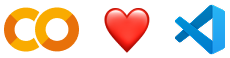

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

In [8]:
!pip install --upgrade google-cloud-aiplatform

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "//content/drive/MyDrive/anjuedtechcopilot-b29b5ab38fcc.json"

In [21]:
import vertexai
from vertexai.generative_models import GenerativeModel

PROJECT_ID = "anjuedtechcopilot"
REGION = "us-central1"

vertexai.init(
    project=PROJECT_ID,
    location=REGION
)

gemini_model = GenerativeModel("gemini-2.0-flash-001")

print("✅ Vertex AI Initialized Successfully")

✅ Vertex AI Initialized Successfully


In [22]:
def generate_question(topic, difficulty="medium"):
    prompt = f"""
    You are a technical interviewer.

    Generate ONE {difficulty} level interview question on the topic: {topic}.

    Only return the question text.
    """

    response = gemini_model.generate_content(prompt)
    return response.text.strip()

In [23]:
def evaluate_answer(question, user_answer):
    prompt = f"""
    You are a senior technical interviewer.

    Question:
    {question}

    Candidate Answer:
    {user_answer}

    Evaluate the answer based on:
    - Technical correctness
    - Depth
    - Clarity
    - Completeness

    Give:
    1. Score out of 10
    2. Strengths
    3. Weaknesses
    4. Suggested improvement
    """

    response = gemini_model.generate_content(prompt)
    return response.text.strip()

In [24]:
def run_interview(topic="Data Science", num_questions=2):
    overall_summary = []

    for i in range(num_questions):
        print(f"\n========== Question {i+1} ==========")

        question = generate_question(topic)
        print("\nInterviewer Question:")
        print(question)

        user_answer = input("\nYour Answer: ")

        print("\nEvaluating...\n")
        feedback = evaluate_answer(question, user_answer)

        print("Feedback:")
        print(feedback)

        overall_summary.append(feedback)

    print("\n========== Interview Completed ==========")

    return overall_summary

In [25]:
summary = run_interview(topic="Data Science", num_questions=2)


========== Question 1 ==========


PermissionDenied: 403 Permission 'aiplatform.endpoints.predict' denied on resource '//aiplatform.googleapis.com/projects/anjuedtechcopilot/locations/us-central1/publishers/google/models/gemini-2.0-flash-001' (or it may not exist). [reason: "IAM_PERMISSION_DENIED"
domain: "aiplatform.googleapis.com"
metadata {
  key: "resource"
  value: "projects/anjuedtechcopilot/locations/us-central1/publishers/google/models/gemini-2.0-flash-001"
}
metadata {
  key: "permission"
  value: "aiplatform.endpoints.predict"
}
]